In [6]:
import subprocess

file_num = 100

In [ ]:
def parse_score_and_turn(exe_path):
    scores = []
    turns = []
    for i in range(file_num):
        print(f"=============== Processing file {i:04d} ===============")
        file_path = f"../tools/in/{i:04d}.txt"
        try:
            with open(file_path, "r") as f:
                process = subprocess.Popen(
                    [exe_path],
                    stdin=f,
                    stdout=subprocess.PIPE,
                    stderr=subprocess.PIPE,
                    text=True
                )
                stdout, stderr = process.communicate()
                score, turn = stdout.strip().split()
                scores.append(int(score))
                turns.append(int(turn))

        except Exception as e:
            print(f"Error processing {file_path}: {e}")
    
    return scores, turns

scores1, turns1 = parse_score_and_turn("../opt.out")
scores2, turns2 = parse_score_and_turn("../greedy.out")

=============== Processing file 0000 ===============
=============== Processing file 0001 ===============
=============== Processing file 0002 ===============
=============== Processing file 0003 ===============
=============== Processing file 0004 ===============
=============== Processing file 0005 ===============
=============== Processing file 0006 ===============
=============== Processing file 0007 ===============
=============== Processing file 0008 ===============
=============== Processing file 0009 ===============
=============== Processing file 0010 ===============
=============== Processing file 0011 ===============
=============== Processing file 0012 ===============
=============== Processing file 0013 ===============
=============== Processing file 0014 ===============
=============== Processing file 0015 ===============
=============== Processing file 0016 ===============
=============== Processing file 0017 ===============
=============== Processing file 0018 =========

In [7]:
from dataclasses import dataclass
from typing import List

# 色ベクトルは長さ3の浮動小数点リスト
Color = List[float]

@dataclass
class Input:
    N: int
    K: int
    H: int
    T: int
    D: int
    own: List[Color]
    target: List[Color]

def parse_input(file_path: str) -> Input:
    """
    ファイルを空白区切りで読み込み、
    最初に N, K, H, T, D の5つの整数を、
    続いて K 個の own カラー (各3つの浮動小数点)、
    H 個の target カラー (各3つの浮動小数点) を読み取ります。
    """
    with open(file_path, 'r') as f:
        # 全トークンを取得
        tokens = f.read().split()
    it = iter(tokens)
    # ヘッダ部
    N = int(next(it))
    K = int(next(it))
    H = int(next(it))
    T = int(next(it))
    D = int(next(it))
    # own カラー K×3
    own: List[Color] = [
        [float(next(it)) for _ in range(3)]
        for _ in range(K)
    ]
    # target カラー H×3
    target: List[Color] = [
        [float(next(it)) for _ in range(3)]
        for _ in range(H)
    ]
    return Input(N=N, K=K, H=H, T=T, D=D, own=own, target=target)

input_datas = []
for i in range(file_num):
    file_path = f"../tools/in/{i:04d}.txt"
    input_data = parse_input(file_path)
    input_datas.append(input_data)
    


In [31]:
len(turns), len(scores1), len(scores2), len(input_datas)

(100, 100, 100, 100)

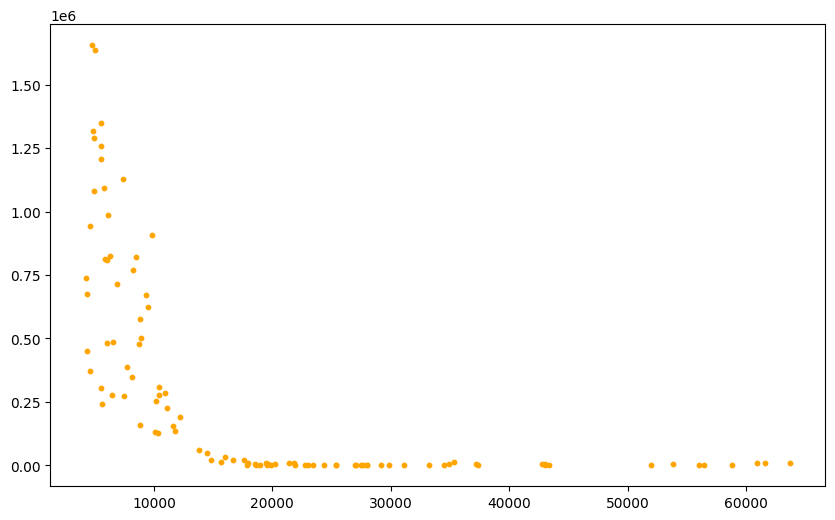

In [43]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10, 6))
plt.scatter(turns, scores1, label='Score 2', color='orange', s=10)

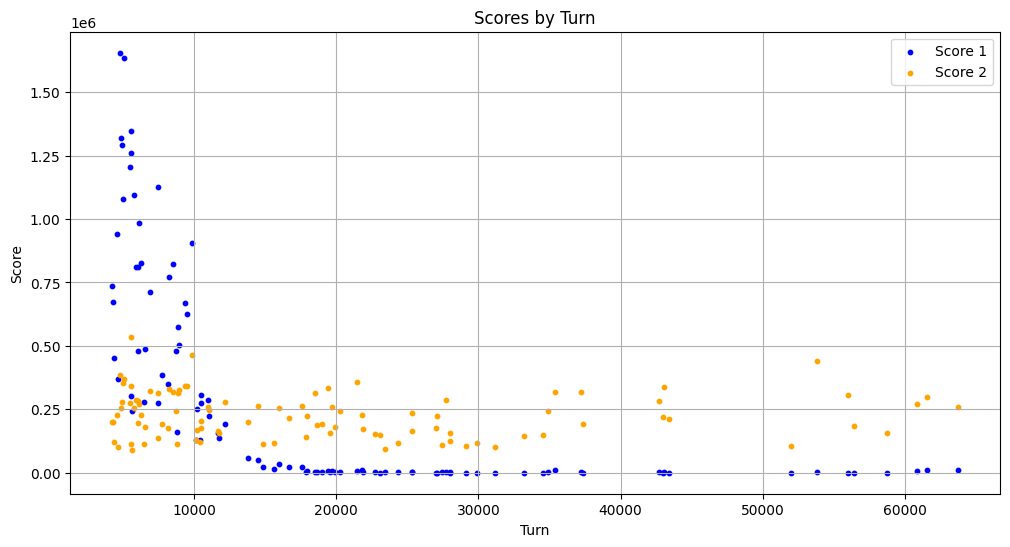

In [44]:
turns = [input_data.T for input_data in input_datas]

# ターン毎の、score1とscore2の分布を可視化



def plot_scores(turns, scores1, scores2):
    plt.figure(figsize=(12, 6))
    plt.scatter(turns, scores1, label='Score 1', color='blue', s=10)
    plt.scatter(turns, scores2, label='Score 2', color='orange', s=10)
    plt.xlabel('Turn')
    plt.ylabel('Score')
    plt.title('Scores by Turn')
    plt.legend()
    plt.grid()
    plt.show()
plot_scores(turns, scores1, scores2)